In [1]:
from google.colab import files
uploaded = files.upload()

Saving Covid Dataset.csv to Covid Dataset (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

In [3]:
!pip install imbalanced-learn -q

In [4]:
df = pd.read_csv("Covid Dataset.csv")

In [5]:
df.head()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Breathing Problem                        5434 non-null   object
 1   Fever                                    5434 non-null   object
 2   Dry Cough                                5434 non-null   object
 3   Sore throat                              5434 non-null   object
 4   Running Nose                             5434 non-null   object
 5   Asthma                                   5434 non-null   object
 6   Chronic Lung Disease                     5434 non-null   object
 7   Headache                                 5434 non-null   object
 8   Heart Disease                            5434 non-null   object
 9   Diabetes                                 5434 non-null   object
 10  Hyper Tension                            5434 non-null   obj

In [7]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 5434
Columns: 21


In [8]:
df.isnull().sum()

,0
Breathing Problem,0
Fever,0
Dry Cough,0
Sore throat,0
Running Nose,0
Asthma,0
Chronic Lung Disease,0
Headache,0
Heart Disease,0
Diabetes,0


In [9]:
df.drop_duplicates(inplace=True)

print(df.shape)

(466, 21)


In [10]:
mapping={
    "Yes":1,
    "No":0
}

df=df.replace(mapping)

In [11]:
for col in df.columns:
    print(col,df[col].unique())

Breathing Problem [1 0]
Fever [1 0]
Dry Cough [1 0]
Sore throat [1 0]
Running Nose [1 0]
Asthma [0 1]
Chronic Lung Disease [0 1]
Headache [0 1]
Heart Disease [0 1]
Diabetes [1 0]
Hyper Tension [1 0]
Fatigue  [1 0]
Gastrointestinal  [1 0]
Abroad travel [0 1]
Contact with COVID Patient [1 0]
Attended Large Gathering [0 1]
Visited Public Exposed Places [1 0]
Family working in Public Exposed Places [1 0]
Wearing Masks [0]
Sanitization from Market [0]
COVID-19 [1 0]


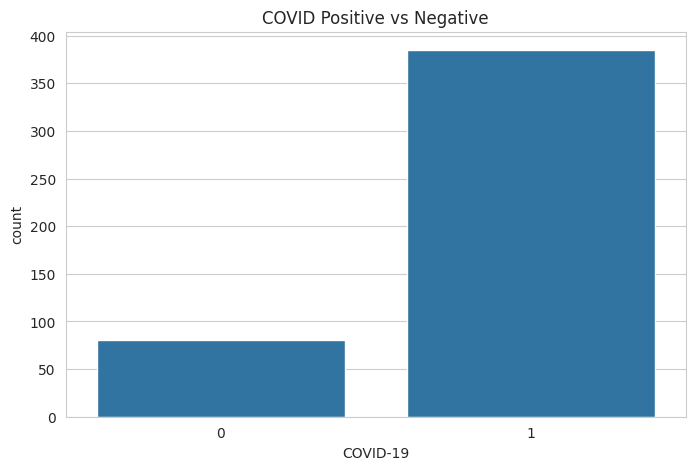

In [12]:
sns.countplot(x="COVID-19",data=df)
plt.title("COVID Positive vs Negative")
plt.show()

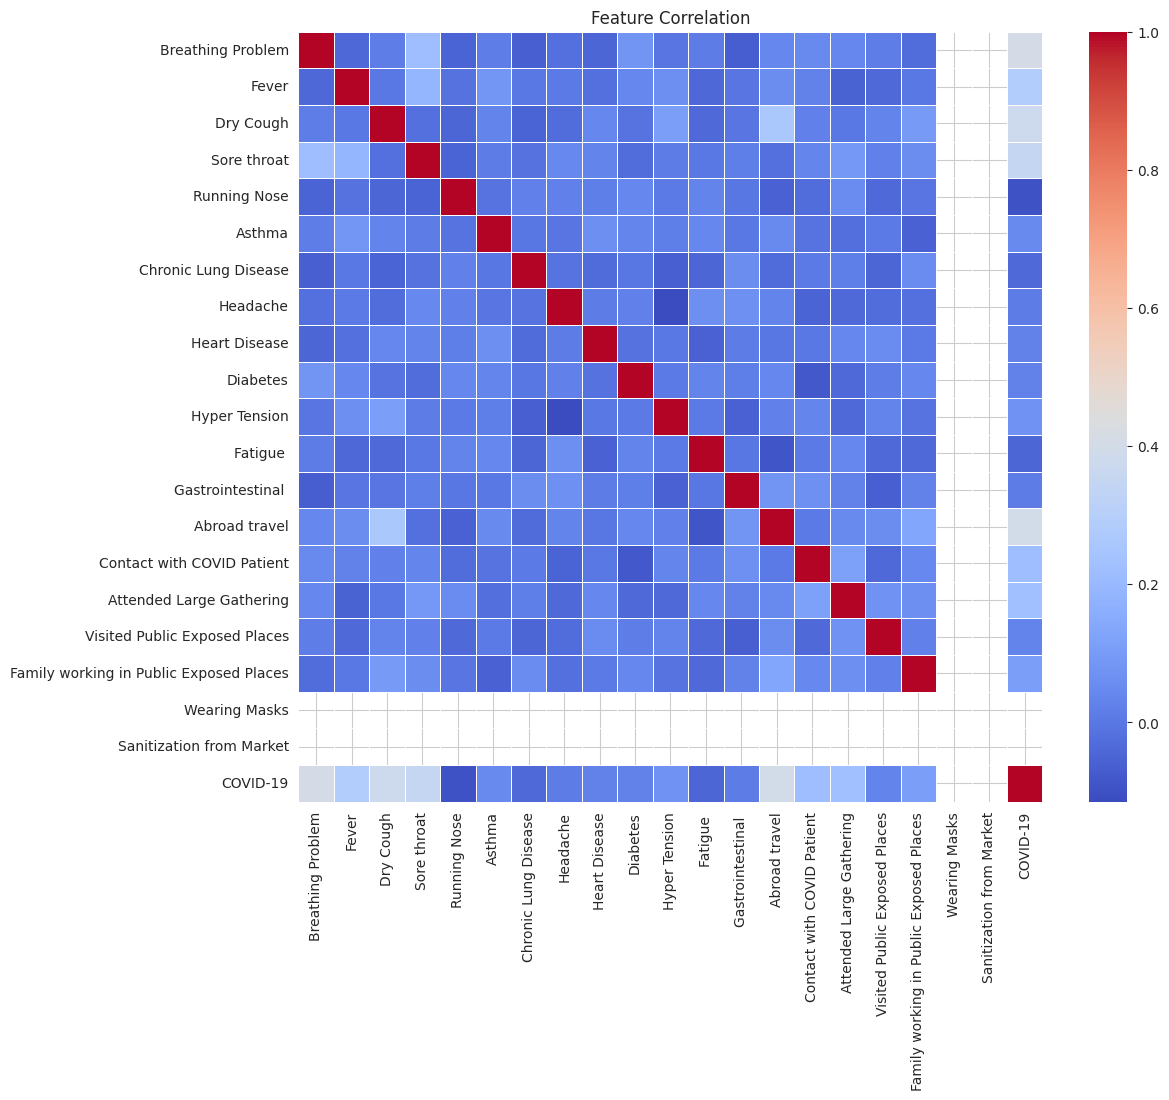

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),cmap="coolwarm",linewidths=0.5)
plt.title("Feature Correlation")
plt.show()

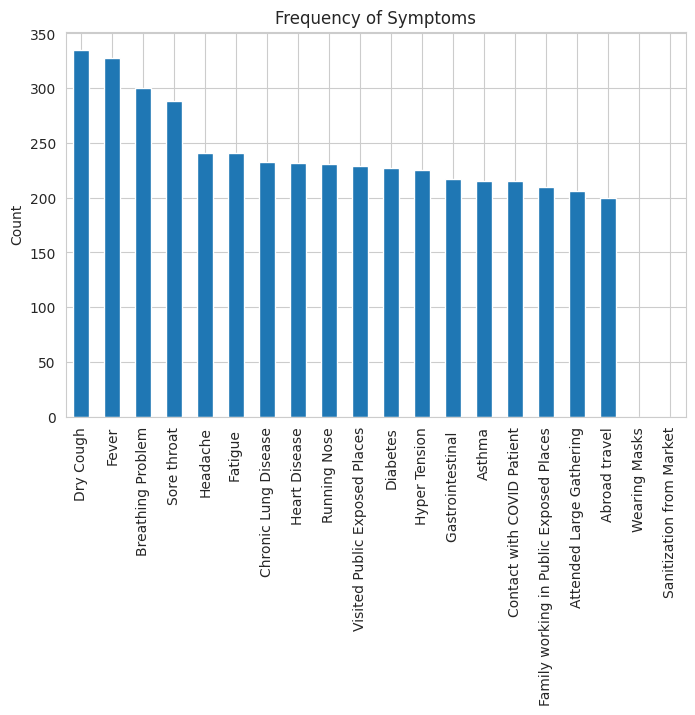

In [14]:
symptom_counts=df.drop("COVID-19",axis=1).sum().sort_values(ascending=False)

symptom_counts.plot(kind="bar")
plt.title("Frequency of Symptoms")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [15]:
X=df.drop("COVID-19",axis=1)
y=df["COVID-19"]

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
smote=SMOTE(random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
COVID-19
1    307
0     65
Name: count, dtype: int64

After SMOTE
COVID-19
1    307
0    307
Name: count, dtype: int64


In [18]:
model=BernoulliNB()

model.fit(X_train_smote,y_train_smote)

BernoulliNB()

In [19]:
params={
    "alpha":[0.1,0.5,1,2,5]
}

grid=GridSearchCV(
    BernoulliNB(),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_smote,y_train_smote)

print("Best Alpha:",grid.best_params_)

Best Alpha: {'alpha': 2}


In [20]:
best_model=grid.best_estimator_

In [21]:
y_pred=best_model.predict(X_test)

y_prob=best_model.predict_proba(X_test)[:,1]

In [22]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

Accuracy : 0.925531914893617
Precision: 0.9176470588235294
Recall   : 1.0
F1 Score : 0.9570552147239264


In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.56      0.72        16
           1       0.92      1.00      0.96        78

    accuracy                           0.93        94
   macro avg       0.96      0.78      0.84        94
weighted avg       0.93      0.93      0.92        94



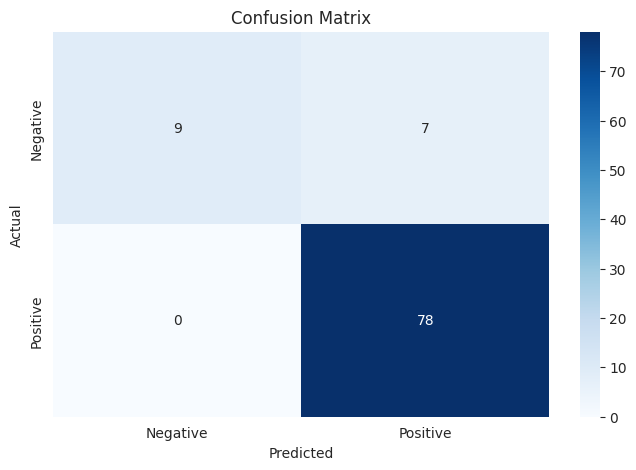

In [24]:
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

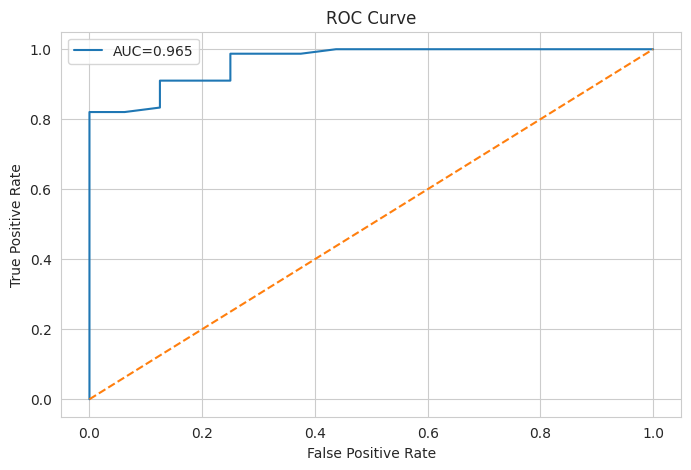

In [25]:
fpr,tpr,_=roc_curve(y_test,y_prob)

auc=roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_model.feature_log_prob_[1]
})

importance=importance.sort_values("Importance",ascending=False)

importance

,Feature,Importance
2,Dry Cough,-0.238535
1,Fever,-0.275961
0,Breathing Problem,-0.293056
3,Sore throat,-0.387935
13,Abroad travel,-0.652197
7,Headache,-0.670889
10,Hyper Tension,-0.677198
11,Fatigue,-0.689937
14,Contact with COVID Patient,-0.696368
8,Heart Disease,-0.696368


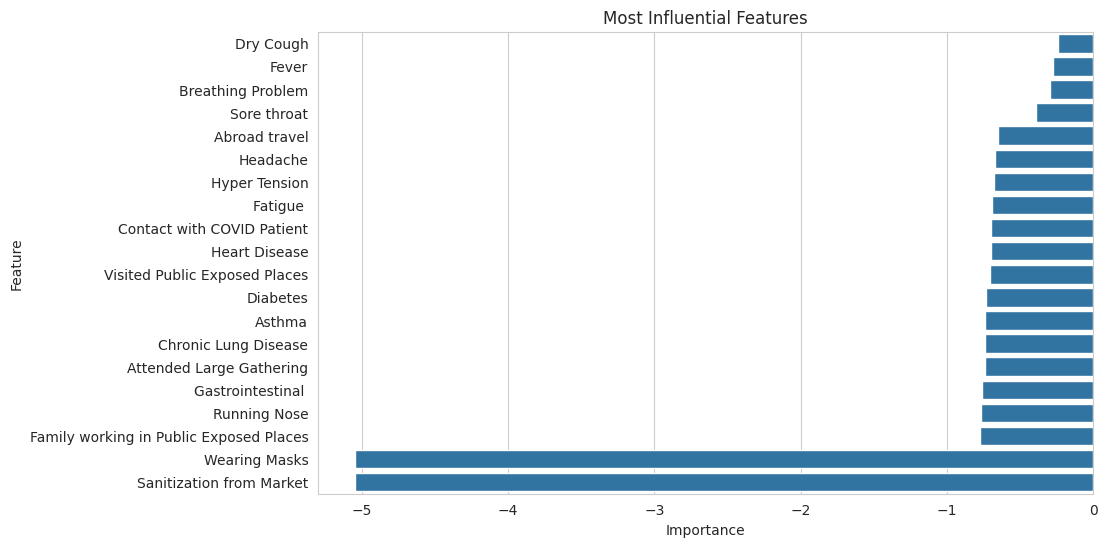

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Most Influential Features")
plt.show()

In [28]:
feature_names=list(X.columns)

user_input={}

print("Enter 1 for Yes and 0 for No\n")

for feature in feature_names:
    value=int(input(f"{feature}: "))
    user_input[feature]=value

user_df=pd.DataFrame([user_input])

prediction=best_model.predict(user_df)[0]

probability=best_model.predict_proba(user_df)[0][1]

print("\nPrediction")

if prediction==1:
    print("COVID Positive")
else:
    print("COVID Negative")

print(f"Probability: {probability*100:.2f}%")

Enter 1 for Yes and 0 for No

Breathing Problem: 1
Fever: 1
Dry Cough: 0
Sore throat: 1
Running Nose: 0
Asthma: 1
Chronic Lung Disease: 0
Headache: 1
Heart Disease: 0
Diabetes: 0
Hyper Tension: 1
Fatigue : 1
Gastrointestinal : 1
Abroad travel: 0
Contact with COVID Patient: 0
Attended Large Gathering: 1
Visited Public Exposed Places: 1
Family working in Public Exposed Places: 0
Wearing Masks: 1
Sanitization from Market: 1

Prediction
COVID Positive
Probability: 98.77%


In [30]:
import numpy as np

# Prior probability P(COVID)
prior = y_train_smote.mean()

# Convert log probabilities to actual probabilities
feature_probs = np.exp(best_model.feature_log_prob_[1])

# Average likelihood P(Symptoms | COVID)
likelihood = feature_probs.mean()

# Evidence P(Symptoms)
evidence = (prior * likelihood) + ((1 - prior) * (1 - likelihood))

# Posterior probability using Bayes Theorem
posterior = (likelihood * prior) / evidence

print(f"Prior Probability P(COVID): {prior:.4f}")
print(f"Likelihood P(Symptoms|COVID): {likelihood:.4f}")
print(f"Evidence P(Symptoms): {evidence:.4f}")
print(f"Posterior Probability P(COVID|Symptoms): {posterior:.4f}")

Prior Probability P(COVID): 0.5000
Likelihood P(Symptoms|COVID): 0.4918
Evidence P(Symptoms): 0.5000
Posterior Probability P(COVID|Symptoms): 0.4918


In [31]:
# Take one patient from the test set
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

# Model prediction
pred = best_model.predict(sample)[0]
prob = best_model.predict_proba(sample)[0]

print("Actual Label:", "Positive" if actual == 1 else "Negative")
print("Predicted:", "Positive" if pred == 1 else "Negative")
print(f"P(Negative | Symptoms): {prob[0]:.4f}")
print(f"P(Positive | Symptoms): {prob[1]:.4f}")

Actual Label: Positive
Predicted: Positive
P(Negative | Symptoms): 0.0006
P(Positive | Symptoms): 0.9994


In [32]:
import joblib

joblib.dump(best_model,"covid_naive_bayes_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
